<a href="https://colab.research.google.com/github/Katerintse/GoogleCollab/blob/main/GCNC_ECG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.special import softmax
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import community
from scipy.special import softmax
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import os
from threadpoolctl import threadpool_info
from threadpoolctl import threadpool_limits

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# --------------------------------------------------------------
def compute_term_variance(X):
    TV = np.var(X, axis=1)  # variance of each row (feature)
    scaler = MinMaxScaler()
    TV_norm = scaler.fit_transform(TV.reshape(-1, 1)).flatten()
    return TV_norm


def compute_laplacian_centrality(G, partition):
    LC = {}
    clusters = {}

    # group nodes by cluster
    for node, c in partition.items():
        clusters.setdefault(c, []).append(node)

    # compute LC only inside each cluster
    for c, nodes in clusters.items():
        subG = G.subgraph(nodes)
        lc_values = nx.laplacian_centrality(subG, normalized=False)
        LC.update(lc_values)

    # convert to list in node order
    LC_values = np.array([LC[i] for i in sorted(LC.keys())])
    scaler = MinMaxScaler()
    LC_norm = scaler.fit_transform(LC_values.reshape(-1, 1)).flatten()
    return LC_norm

# --------------------------------------------------------------
def _representatives_by_partition(G, partition, weight='weight'):
    """
    For each community, pick 1 representative node.
    Here: representative = node with highest weighted degree (strength)
    within the community subgraph.
    """
    communities = {}
    for node, c in partition.items():
        communities.setdefault(c, []).append(node)

    reps = []
    for c, nodes in communities.items():
        subG = G.subgraph(nodes)
        # weighted degree (strength)
        strengths = dict(subG.degree(weight=weight))
        rep = max(strengths, key=strengths.get)
        reps.append(rep)

    reps.sort()
    return reps


def auto_select_resolution(G, resolutions, weight='weight', consensus_ratio=0.6):
    """
    Multi-resolution consensus selection:
      1) Run Louvain across multiple resolutions
      2) Pick 1 representative node per community for each resolution
      3) Count how often each node becomes representative
      4) Choose the resolution whose representative set best matches the
         high-frequency (stable) representatives.

    Returns: (best_resolution, best_partition)
    """
    partitions = {}
    reps_by_res = {}
    rep_counter = Counter()

    # 1) run partitions + reps across resolutions
    for r in resolutions:
        part = community.best_partition(G, weight=weight, resolution=float(r))
        reps = _representatives_by_partition(G, part, weight=weight)
        partitions[r] = part
        reps_by_res[r] = reps
        rep_counter.update(reps)

    # 2) consensus reps = reps appearing frequently across resolutions
    m = len(resolutions)
    min_freq = int(np.ceil(consensus_ratio * m))
    consensus = {node for node, cnt in rep_counter.items() if cnt >= min_freq}

    # if consensus is empty (rare), fall back to top-K by frequency
    if len(consensus) == 0:
        # choose top ~25% most frequent reps
        k = max(1, int(np.ceil(0.25 * len(rep_counter))))
        consensus = {node for node, _ in rep_counter.most_common(k)}

    # 3) score each resolution by how well it matches consensus + frequency mass
    best_r = None
    best_score = -1e18
    for r in resolutions:
        reps = set(reps_by_res[r])
        inter = len(reps & consensus)
        union = len(reps | consensus) if len(reps | consensus) > 0 else 1
        jaccard = inter / union

        # frequency mass encourages picking reps that are stable across resolutions
        freq_mass = sum(rep_counter[node] for node in reps)

        # combined score (keep simple/robust)
        score = (10.0 * jaccard) + (1.0 * freq_mass)

        if score > best_score:
            best_score = score
            best_r = r

    return float(best_r), partitions[best_r]

# --------------------------------------------------------------
def pearson_similarity(x, y):
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    numerator = np.sum((x - mean_x) * (y - mean_y))
    denominator = np.sqrt(np.sum((x - mean_x)**2)) * np.sqrt(np.sum((y - mean_y)**2))
    if denominator == 0:
        return 0.0
    return np.abs(numerator / denominator)


# ============================================
# 1. Load data  (28 samples × 5 RQA features)
# ============================================
data = np.loadtxt("rqa_Xtrain_all6.txt", skiprows=1)#, comments="#")
Xs = data[:, 1:]
print("rqa vectors shape :", Xs.shape)

n_eps = 10
Xtrainimb_shape = Xs.shape[0] // n_eps
print("timeseries shape:", Xtrainimb_shape)



rqa vectors shape : (400, 5)
timeseries shape: 40


In [ ]:
with threadpool_limits(limits=1):


    eps_id = []
    for tms_i in range(Xtrainimb_shape):

        #print(tms_i)
        X = Xs[(n_eps * tms_i) : (n_eps + n_eps * tms_i)]

        # ============================================
        # 2. Pearson correlation similarity matrix
        # ============================================
        Xc = X - X.mean(axis=1, keepdims=True)
        Xc /= np.linalg.norm(Xc, axis=1, keepdims=True)
        S = np.abs(Xc @ Xc.T)
        #print("\nPearson similarity matrix:", S)
        # np.savetxt('Stest.txt', S)

        # ============================================
        # 3. Softmax normalization (nonlinear scaling)
        # ============================================
        #S_softmax = softmax(S, axis=0)
        #S_softmax = S
        w_mean = np.mean(S)
        w_std  = np.std(S)
        S_softmax = 1.0 / (1.0 + np.exp(-(S - w_mean) / w_std))
        #print("\nSoftmax-normalized similarity matrix:")
        #print(S_softmax)

        # ============================================
        # 4. Build Network Graph
        #    (edges only if similarity > threshold)
        # ============================================
        n = X.shape[0]
        G = nx.Graph()

        G.add_nodes_from(range(n))
        for i in range(n):
            for j in range(i+1, n):

                G.add_edge(i, j, weight=float(S_softmax[i, j]))
        #print(f"\nGraph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

        # ============================================
        # 6. Community Detection using Louvain Method
        #    + Automated resolution selection (added)
        # ============================================
        resolutions = np.linspace(0.8, 1.0, 16)
        best_resolution, partition = auto_select_resolution(G, resolutions,
                                                            weight='weight',
                                                            consensus_ratio=0.6)
        print("Selected resolution:", best_resolution)

        #partition = community.best_partition(G, weight='weight', resolution=1.3)
        num_clusters = len(set(partition.values()))
        print('Number of clusters: ', num_clusters)

        # ============================================
        # 7. Compute Feature Influence Scores
        # ==========================================================
        TV = compute_term_variance(X)
        LC = compute_laplacian_centrality(G, partition)
        Influence = (TV * LC)
        #np.savetxt('Influencetest.txt', Influence)
        eps_id.append(np.argsort(Influence)[::-1][0])
        #print(np.argsort(Influence)[::-1][0])
        print(np.argsort(Influence)[::-1][:10])
        #print(Influence[np.argsort(Influence)[::-1]][:10])

    #np.savetxt('eps_id_all6.txt', eps_id)

Selected resolution: 0.8
Number of clusters:  2
[9 8 7 6 5 4 3 1 2 0]
Selected resolution: 0.8133333333333334
Number of clusters:  2
[9 7 8 6 5 4 3 2 1 0]
Selected resolution: 0.8
Number of clusters:  2
[5 4 3 7 8 6 2 1 9 0]
Selected resolution: 0.8
Number of clusters:  2
[9 8 6 7 5 4 3 2 1 0]
Selected resolution: 0.8266666666666667
Number of clusters:  2
[9 7 6 8 5 4 3 2 1 0]
Selected resolution: 0.8
Number of clusters:  2
[9 8 7 6 5 4 3 2 1 0]
Selected resolution: 0.8
Number of clusters:  2
[9 7 8 6 5 4 3 2 1 0]
Selected resolution: 0.8
Number of clusters:  2
[9 7 8 6 5 3 4 2 1 0]
Selected resolution: 0.8
Number of clusters:  2
[9 8 7 6 5 0 3 4 2 1]
Selected resolution: 0.8
Number of clusters:  2
[5 4 3 9 8 7 2 1 6 0]
Selected resolution: 0.8
Number of clusters:  2
[9 8 7 6 5 4 0 3 2 1]
Selected resolution: 0.8
Number of clusters:  2
[9 8 6 7 5 4 2 1 3 0]
Selected resolution: 0.8
Number of clusters:  2
[9 8 7 6 2 1 5 4 3 0]
Selected resolution: 0.8
Number of clusters:  2
[5 4 3 7 8 9

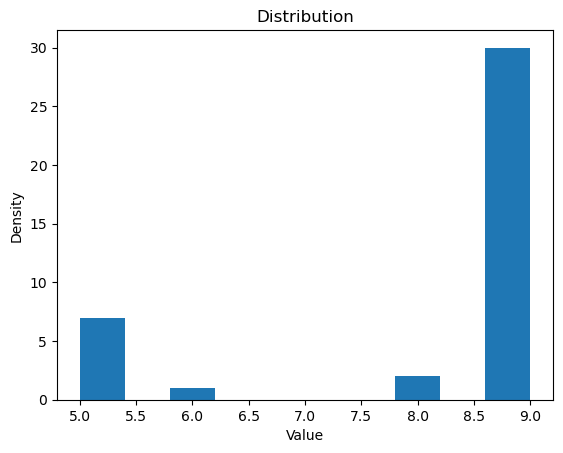

In [ ]:
epsilons = np.array(eps_id).flatten()

counts, bin_edges = np.histogram(epsilons, bins=11)


plt.hist(epsilons, bins=10)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution")
plt.show()

In [ ]:
counts

array([ 7,  0,  1,  0,  0,  0,  0,  0,  2,  0, 30])

In [ ]:
bin_edges

array([5.        , 5.36363636, 5.72727273, 6.09090909, 6.45454545,
       6.81818182, 7.18181818, 7.54545455, 7.90909091, 8.27272727,
       8.63636364, 9.        ])